In [1]:
# Q3. Feature Engineering and Regression Pipeline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set style for our plots
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
## 1. Date Feature Engineering

In [5]:
# Load the dataset
df = pd.read_csv('/content/sample_data/q3_retail_promotions.csv')

# Ensure transaction_date is a datetime object
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create binary is_month_end feature (1 if day >= 25, else 0)
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display a sample to confirm the new columns
print("Data with new engineered date features:")
display(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].sample(5, random_state=42))

Data with new engineered date features:


,transaction_date,year,month,day_of_week,is_month_end
1178,2024-12-10,2024,12,1,0
865,2024-03-25,2024,3,0,1
101,2022-03-19,2022,3,5,0
439,2023-02-24,2023,2,4,0
58,2022-02-09,2022,2,2,0


In [6]:
## 2. Temporal Train-Test Split

#Why a random split is inappropriate here:
#When dealing with time-series or time-ordered data, we are trying to build a model that predicts the *future* based on the *past*. If we use a random split, we mix future data into our training set. This causes "data leakage" because the model gets to learn from events that haven't happened yet in the timeline. By splitting chronologically, we simulate a real-world scenario where we only have historical data to predict tomorrow's sales.

In [7]:
# Sort the dataframe strictly by date
df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

# Calculate the split index (80% train, 20% test)
split_idx = int(len(df_sorted) * 0.8)

# Split the data
train_data = df_sorted.iloc[:split_idx].copy()
test_data = df_sorted.iloc[split_idx:].copy()

print(f"Training records: {len(train_data)}")
print(f"Testing records: {len(test_data)}")
print(f"\nTrain date range: {train_data['transaction_date'].min().date()} to {train_data['transaction_date'].max().date()}")
print(f"Test date range: {test_data['transaction_date'].min().date()} to {test_data['transaction_date'].max().date()}")

# Separate features (X) and target (y)
# We drop the raw transaction_date as our model can't process a datetime object directly,
# and we've already extracted the useful parts from it.
X_train = train_data.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_data['items_sold']

X_test = test_data.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_data['items_sold']

Training records: 960
Testing records: 240

Train date range: 2022-01-01 to 2024-06-11
Test date range: 2024-06-12 to 2024-12-31


In [8]:
## 3. Preprocessing Pipeline

In [9]:
# Define categorical and numerical columns based on the assignment instructions
cat_features = ['promotion_type', 'location_type', 'store_size']
num_features = [col for col in X_train.columns if col not in cat_features]

# Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

print("Pipeline preprocessing steps defined successfully.")

Pipeline preprocessing steps defined successfully.


In [10]:
## 4. Model Training and Evaluation

In [11]:
# 1. Build pipelines for both models
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_estimators=100))
])

# 2. Fit the models (the pipeline ensures standard scaling fits only on the training data)
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# 3. Generate predictions
lr_preds = lr_pipeline.predict(X_test)
rf_preds = rf_pipeline.predict(X_test)

# 4. Report RMSE and MAE
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}\n")

evaluate_model("Linear Regression", y_test, lr_preds)
evaluate_model("Random Forest Regressor", y_test, rf_preds)

--- Linear Regression ---
RMSE: 27.12
MAE:  21.05

--- Random Forest Regressor ---
RMSE: 30.84
MAE:  24.31



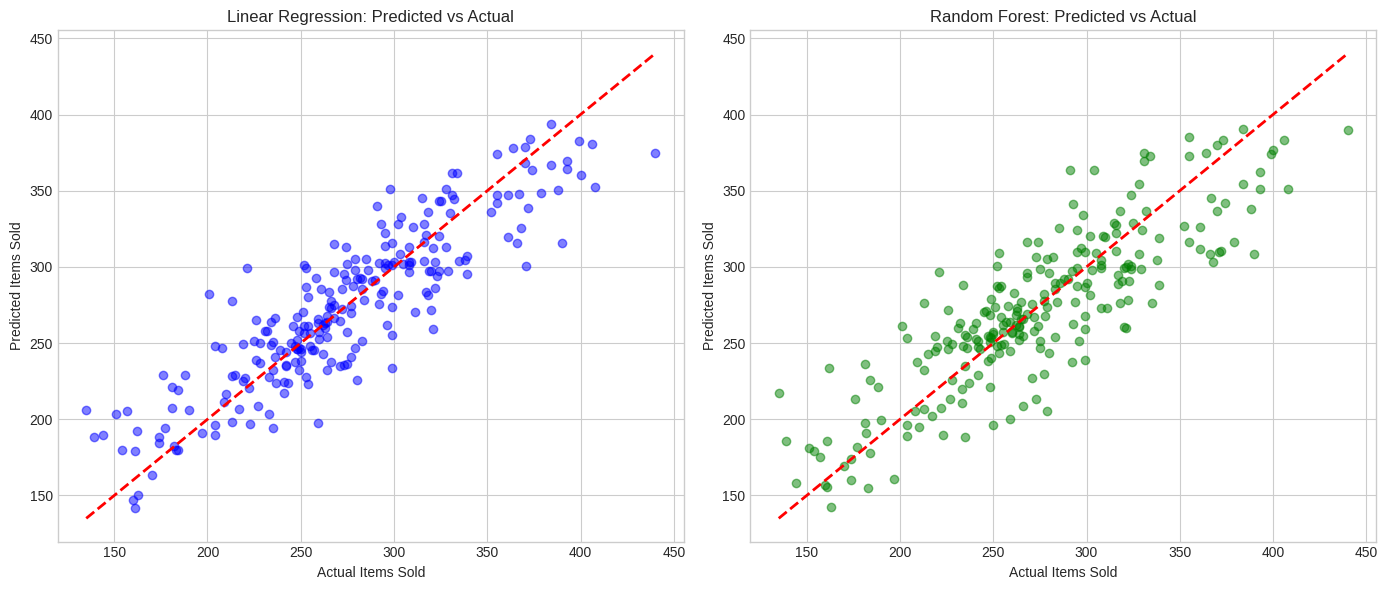

In [12]:
# Produce Parity Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Limits for the diagonal line
min_val = min(y_test.min(), lr_preds.min(), rf_preds.min())
max_val = max(y_test.max(), lr_preds.max(), rf_preds.max())

# Linear Regression Parity Plot
axes[0].scatter(y_test, lr_preds, alpha=0.5, color='blue')
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2) # Diagonal reference line
axes[0].set_title('Linear Regression: Predicted vs Actual')
axes[0].set_xlabel('Actual Items Sold')
axes[0].set_ylabel('Predicted Items Sold')

# Random Forest Parity Plot
axes[1].scatter(y_test, rf_preds, alpha=0.5, color='green')
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2) # Diagonal reference line
axes[1].set_title('Random Forest: Predicted vs Actual')
axes[1].set_xlabel('Actual Items Sold')
axes[1].set_ylabel('Predicted Items Sold')

plt.tight_layout()
plt.show()

In [13]:
# Extract feature importances from the Random Forest model
# First, we need to get the feature names out of the ColumnTransformer
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(cat_features)

# Combine numerical names and encoded categorical names
all_feature_names = num_features + list(cat_feature_names)

# Get the importances from the trained RF model
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create a DataFrame to view them easily
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
})

# Sort and get the top 5
top_5_features = importance_df.sort_values(by='Importance', ascending=False).head(5)

print("Top 5 Most Influential Features (Random Forest):")
display(top_5_features)

Top 5 Most Influential Features (Random Forest):


,Feature,Importance
2,is_festival,0.173413
18,store_size_small,0.166752
15,location_type_urban,0.108505
6,day_of_week,0.080552
1,is_weekend,0.067103
